# Predicting Laptop Price — Multiple Linear Regression from Scratch

**Problem.** A tech retailer wants to predict a laptop's retail price (USD) from its hardware specs.
All 7 features are numeric or simple binary flags, so we can go straight to multiple linear regression.

| feature | meaning | units |
|---|---|---|
| `screen_size`    | screen diagonal            | inches |
| `ram_gb`         | memory capacity            | GB |
| `storage_gb`     | SSD capacity               | GB |
| `weight_kg`      | laptop weight              | kg |
| `cpu_speed`      | base clock speed           | GHz |
| `battery_life`   | average battery life       | hours |
| `is_touchscreen` | 1 = touchscreen, 0 = normal| flag |

**Target** $y$: retail price in USD.

**The model.** With $n = 7$ features, the prediction for one laptop $\mathbf{x}$ is

$$f_{\mathbf{w},b}(\mathbf{x}) = \mathbf{w}\cdot\mathbf{x} + b = w_0 x_0 + w_1 x_1 + \dots + w_6 x_6 + b$$

**The goal.** Find the $\mathbf{w}$ (7 numbers) and $b$ (1 number) that minimize the squared error cost

$$J(\mathbf{w},b) = \frac{1}{2m}\sum_{i=0}^{m-1}\left(f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}\right)^2$$

We'll do it with batch gradient descent, written by hand with NumPy — no scikit-learn.

## 1. The dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
plt.style.use('seaborn-v0_8-whitegrid')

feature_names = ['screen_size', 'ram_gb', 'storage_gb', 'weight_kg',
                 'cpu_speed', 'battery_life', 'is_touchscreen']

# Each row is one laptop, columns follow feature_names above.
X_train = np.array([
    [13.3,  8,  256, 1.2, 2.4, 10, 0],
    [15.6, 16,  512, 1.8, 3.2,  8, 1],
    [14.0,  8,  512, 1.4, 2.8, 12, 0],
    [15.6, 32, 1024, 2.1, 4.0,  6, 1],
    [13.3, 16,  256, 1.1, 3.0, 11, 0],
    [17.3, 16, 1024, 2.6, 3.5,  5, 0],
    [14.0,  4,  128, 1.5, 1.8,  9, 0],
    [15.6, 16,  512, 1.9, 3.2,  7, 0],
])

# Price in USD
y_train = np.array([750, 1200, 890, 1950, 1100, 1450, 420, 1050], dtype=float)

m, n = X_train.shape
print(f"m = {m} training examples, n = {n} features")
print(f"X_train shape: {X_train.shape},  y_train shape: {y_train.shape}")

header = "  ID | " + " | ".join(f"{f:>14s}" for f in feature_names) + " |    price"
print("\n" + header)
print("-" * len(header))
for i in range(m):
    row = " | ".join(f"{v:>14g}" for v in X_train[i])
    print(f"  {i+1:>2d} | {row} | ${y_train[i]:>7.0f}")

m = 8 training examples, n = 7 features
X_train shape: (8, 7),  y_train shape: (8,)

  ID |    screen_size |         ram_gb |     storage_gb |      weight_kg |      cpu_speed |   battery_life | is_touchscreen |    price
--------------------------------------------------------------------------------------------------------------------------------------
   1 |           13.3 |              8 |            256 |            1.2 |            2.4 |             10 |              0 | $    750
   2 |           15.6 |             16 |            512 |            1.8 |            3.2 |              8 |              1 | $   1200
   3 |             14 |              8 |            512 |            1.4 |            2.8 |             12 |              0 | $    890
   4 |           15.6 |             32 |           1024 |            2.1 |              4 |              6 |              1 | $   1950
   5 |           13.3 |             16 |            256 |            1.1 |              3 |             1

## 2. Feature scaling (z-score normalization)

Look at the ranges: `storage_gb` runs 128–1024 while `weight_kg` runs 1.1–2.6. That's a **~400× spread**.

Gradient descent on raw features like this is miserable — the cost surface becomes a long thin valley,
so any learning rate small enough to keep the `storage_gb` direction stable is far too small for `weight_kg`,
and training crawls (or diverges).

The fix is z-score normalization. For each feature $j$:

$$x^{(i)}_{j,\text{norm}} = \frac{x^{(i)}_j - \mu_j}{\sigma_j}$$

where $\mu_j$ is that feature's mean and $\sigma_j$ its standard deviation. Every feature then has
mean 0 and standard deviation 1, and the valley becomes round.

In [2]:
def zscore_normalize_features(X):
    """
    Z-score normalize each column (feature) of X.

    Args:
        X (ndarray (m, n)): input data
    Returns:
        X_norm (ndarray (m, n)): normalized data
        mu     (ndarray (n,)) : mean of each feature
        sigma  (ndarray (n,)) : standard deviation of each feature
    """
    mu    = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma


X_norm, mu, sigma = zscore_normalize_features(X_train)

print("Before scaling")
print(f"  peak-to-peak range per feature: {np.ptp(X_train, axis=0)}")
print("\nAfter scaling")
print(f"  peak-to-peak range per feature: {np.ptp(X_norm, axis=0)}")
print(f"  mean per feature (should be ~0): {np.mean(X_norm, axis=0)}")
print(f"  std  per feature (should be  1): {np.std(X_norm, axis=0)}")

print("\nSaved scaling parameters (we need these later to un-scale the weights):")
for j, name in enumerate(feature_names):
    print(f"  {name:>14s}:  mu = {mu[j]:>8.3f}   sigma = {sigma[j]:>8.3f}")

Before scaling
  peak-to-peak range per feature: [  4.   28.  896.    1.5   2.2   7.    1. ]

After scaling
  peak-to-peak range per feature: [3.03  3.507 2.832 3.198 3.496 3.055 2.309]
  mean per feature (should be ~0): [ 0.  0.  0.  0.  0. -0. -0.]
  std  per feature (should be  1): [1. 1. 1. 1. 1. 1. 1.]

Saved scaling parameters (we need these later to un-scale the weights):
     screen_size:  mu =   14.837   sigma =    1.320
          ram_gb:  mu =   14.500   sigma =    7.984
      storage_gb:  mu =  528.000   sigma =  316.380
       weight_kg:  mu =    1.700   sigma =    0.469
       cpu_speed:  mu =    2.987   sigma =    0.629
    battery_life:  mu =    8.500   sigma =    2.291
  is_touchscreen:  mu =    0.250   sigma =    0.433


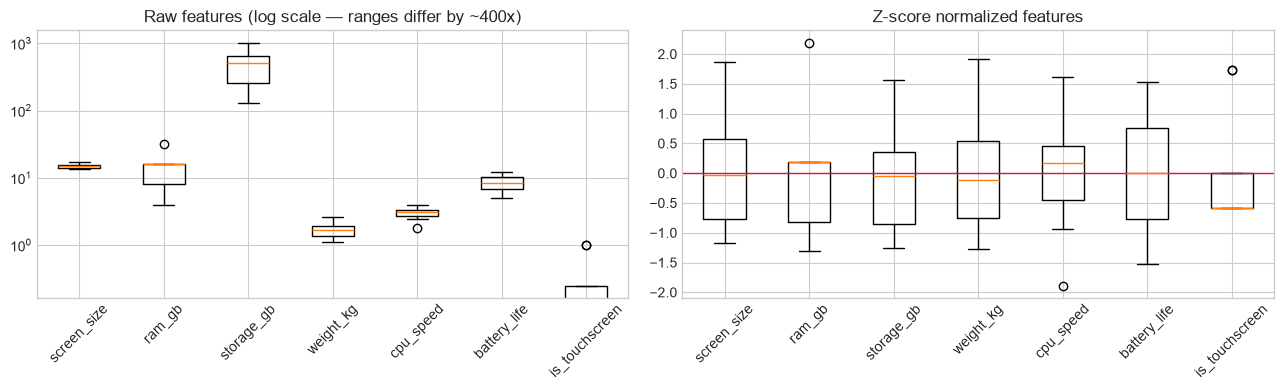

In [3]:
# Visual check: the raw features live on wildly different scales, the normalized ones don't.
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].boxplot(X_train, tick_labels=feature_names)
ax[0].set_title('Raw features (log scale — ranges differ by ~400x)')
ax[0].set_yscale('log')
ax[0].tick_params(axis='x', rotation=45)

ax[1].boxplot(X_norm, tick_labels=feature_names)
ax[1].set_title('Z-score normalized features')
ax[1].axhline(0, color='crimson', lw=1)
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. The cost function

$$J(\mathbf{w},b) = \frac{1}{2m}\sum_{i=0}^{m-1}\left(f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}\right)^2$$

Vectorized: predictions for *all* examples at once are `X @ w + b`, and the cost is
half the mean of the squared errors.

In [4]:
def compute_cost(X, y, w, b):
    """
    Squared error cost for multiple linear regression.

    Args:
        X (ndarray (m, n)): input data
        y (ndarray (m,))  : target values
        w (ndarray (n,))  : model weights
        b (scalar)        : model bias
    Returns:
        cost (scalar): the value of J(w, b)
    """
    m = X.shape[0]
    f_wb = X @ w + b            # (m,) predictions for every example
    err  = f_wb - y             # (m,) residuals
    cost = np.sum(err ** 2) / (2 * m)
    return cost


# Sanity check with zero parameters: cost should be half the mean squared price.
w_zero = np.zeros(n)
b_zero = 0.0
print(f"J(w=0, b=0)      = {compute_cost(X_norm, y_train, w_zero, b_zero):,.2f}")
print(f"expected         = {np.sum(y_train**2) / (2*m):,.2f}")

# And with b = mean price (the best possible constant model), cost drops a lot.
print(f"\nJ(w=0, b=mean y) = {compute_cost(X_norm, y_train, w_zero, y_train.mean()):,.2f}")

J(w=0, b=0)      = 699,281.25
expected         = 699,281.25

J(w=0, b=mean y) = 92,905.47


## 4. The gradient

We need the partial derivative of $J$ with respect to every parameter:

$$\frac{\partial J}{\partial w_j} = \frac{1}{m}\sum_{i=0}^{m-1}\left(f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}\right)x^{(i)}_j
\qquad
\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=0}^{m-1}\left(f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}\right)$$

All 7 $w$-derivatives fall out of a single matrix product: `X.T @ err / m`.

In [5]:
def compute_gradient(X, y, w, b):
    """
    Gradient of the squared error cost for multiple linear regression.

    Args:
        X (ndarray (m, n)): input data
        y (ndarray (m,))  : target values
        w (ndarray (n,))  : model weights
        b (scalar)        : model bias
    Returns:
        dj_dw (ndarray (n,)): gradient w.r.t. each weight
        dj_db (scalar)      : gradient w.r.t. the bias
    """
    m = X.shape[0]
    err   = (X @ w + b) - y     # (m,)
    dj_dw = (X.T @ err) / m     # (n,)  -- one dot product per feature
    dj_db = np.sum(err) / m     # scalar
    return dj_dw, dj_db


# Verify the analytic gradient against a numerical finite-difference estimate.
w_test = np.array([50., 120., 80., -30., 40., -10., 25.])
b_test = 900.

dj_dw, dj_db = compute_gradient(X_norm, y_train, w_test, b_test)

eps = 1e-4
num_dw = np.zeros(n)
for j in range(n):
    w_plus, w_minus = w_test.copy(), w_test.copy()
    w_plus[j]  += eps
    w_minus[j] -= eps
    num_dw[j] = (compute_cost(X_norm, y_train, w_plus,  b_test) -
                 compute_cost(X_norm, y_train, w_minus, b_test)) / (2 * eps)
num_db = (compute_cost(X_norm, y_train, w_test, b_test + eps) -
          compute_cost(X_norm, y_train, w_test, b_test - eps)) / (2 * eps)

print("analytic dj_dw :", dj_dw)
print("numerical dj_dw:", num_dw)
print("max abs diff   :", np.max(np.abs(dj_dw - num_dw)))
print(f"\nanalytic dj_db : {dj_db:.6f}")
print(f"numerical dj_db: {num_db:.6f}")
print("\nGradient check PASSED" if np.allclose(dj_dw, num_dw, atol=1e-4) else "\nGradient check FAILED")

analytic dj_dw : [ -79.099 -162.74  -143.417  -82.824 -164.943   78.849  -97.35 ]
numerical dj_dw: [ -79.099 -162.74  -143.417  -82.824 -164.943   78.849  -97.35 ]
max abs diff   : 1.024736775434576e-07

analytic dj_db : -201.250000
numerical dj_db: -201.250000

Gradient check PASSED


## 5. Gradient descent

Repeat until convergence, updating **all** parameters simultaneously:

$$w_j := w_j - \alpha\frac{\partial J}{\partial w_j}\quad(j = 0 \dots n-1)
\qquad
b := b - \alpha\frac{\partial J}{\partial b}$$

In [6]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters, cost_every=None):
    """
    Run batch gradient descent to fit w and b.

    Args:
        X (ndarray (m, n)) : input data
        y (ndarray (m,))   : target values
        w_in (ndarray (n,)): initial weights
        b_in (scalar)      : initial bias
        alpha (float)      : learning rate
        num_iters (int)    : number of iterations
        cost_every (int)   : record the cost every this many iterations
    Returns:
        w (ndarray (n,))   : fitted weights
        b (scalar)         : fitted bias
        J_history (list)   : recorded cost values
    """
    w = w_in.copy()          # copy so we don't mutate the caller's array
    b = b_in
    J_history = []
    cost_every = cost_every or max(1, num_iters // 100)

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw     # simultaneous update
        b = b - alpha * dj_db

        if i % cost_every == 0 or i == num_iters - 1:
            J_history.append((i, compute_cost(X, y, w, b)))

    return w, b, J_history

### Picking the learning rate

Too small and it crawls; too large and it diverges. Let's just try a few and look at the cost curves.

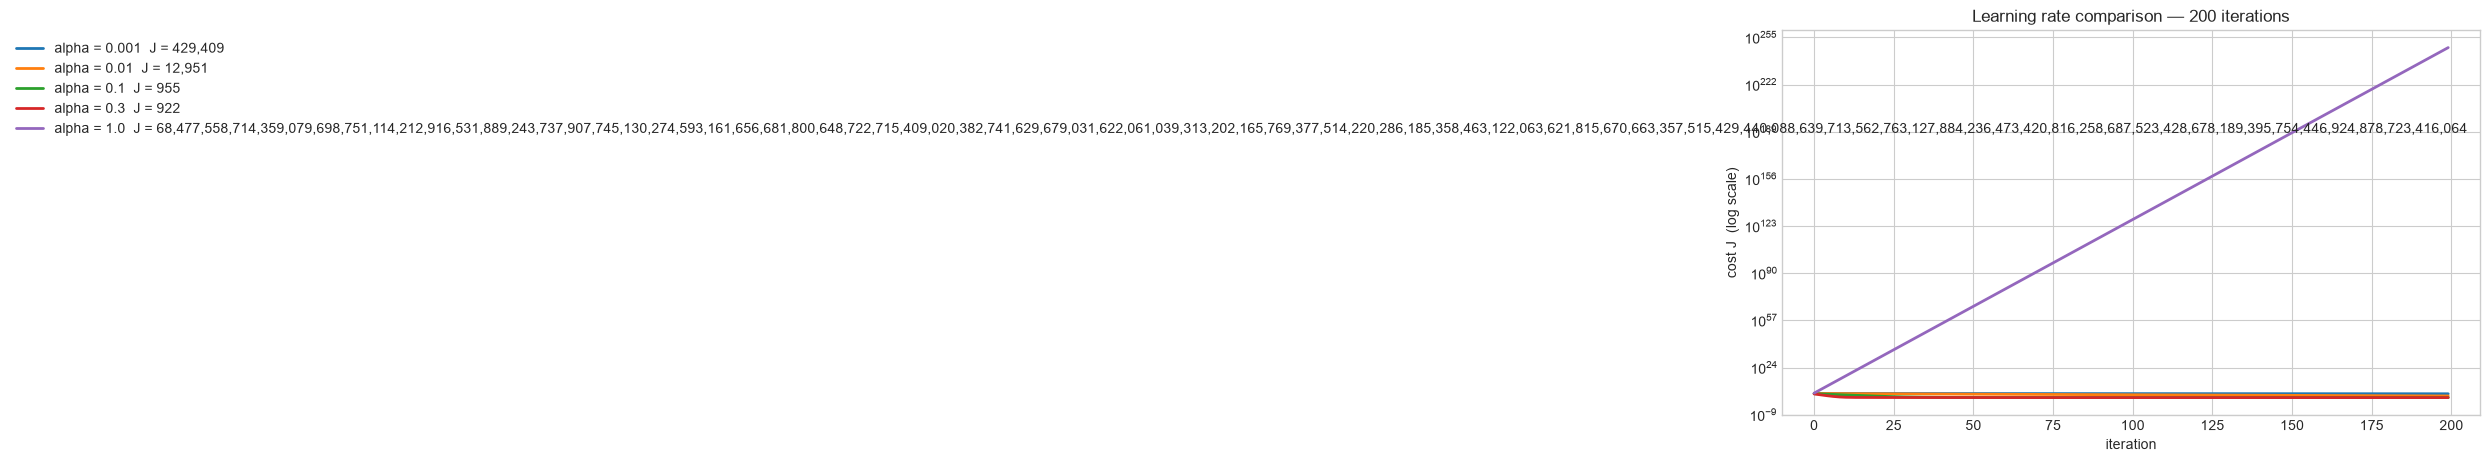

alpha = 1.0 blows up (the curve shoots off the top / goes to NaN).
alpha = 0.3 is the fastest rate that still converges cleanly -- we'll use it.


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

for alpha in [0.001, 0.01, 0.1, 0.3, 1.0]:
    _, _, hist = gradient_descent(X_norm, y_train, np.zeros(n), 0.0,
                                  alpha, num_iters=200, cost_every=1)
    iters  = [h[0] for h in hist]
    costs  = [h[1] for h in hist]
    final  = costs[-1]
    label  = f"alpha = {alpha}" + ("  (DIVERGES)" if not np.isfinite(final) else f"  J = {final:,.0f}")
    ax.plot(iters, costs, label=label, lw=2)

ax.set_yscale('log')
ax.set_xlabel('iteration')
ax.set_ylabel('cost J  (log scale)')
ax.set_title('Learning rate comparison — 200 iterations')
ax.legend()
plt.show()

print("alpha = 1.0 blows up (the curve shoots off the top / goes to NaN).")
print("alpha = 0.3 is the fastest rate that still converges cleanly -- we'll use it.")

### Train the model

In [8]:
alpha     = 0.3
num_iters = 10_000

w_init = np.zeros(n)
b_init = 0.0

w_norm, b_norm, J_history = gradient_descent(
    X_norm, y_train, w_init, b_init, alpha, num_iters
)

print(f"Trained for {num_iters:,} iterations at alpha = {alpha}\n")
print(f"final cost J    = {compute_cost(X_norm, y_train, w_norm, b_norm):,.4f}")
print(f"b (normalized)  = {b_norm:,.2f}   <- this is just the mean price")
print(f"mean price      = {y_train.mean():,.2f}\n")

print("w in NORMALIZED units -- 'dollars per 1 standard deviation of this feature':")
for j, name in enumerate(feature_names):
    print(f"  {name:>14s}:  {w_norm[j]:>10.2f}")

Trained for 10,000 iterations at alpha = 0.3

final cost J    = 766.9908
b (normalized)  = 1,101.25   <- this is just the mean price
mean price      = 1,101.25

w in NORMALIZED units -- 'dollars per 1 standard deviation of this feature':
     screen_size:      299.66
          ram_gb:      261.53
      storage_gb:      362.70
       weight_kg:     -475.08
       cpu_speed:      -58.43
    battery_life:      -53.46
  is_touchscreen:       -6.09


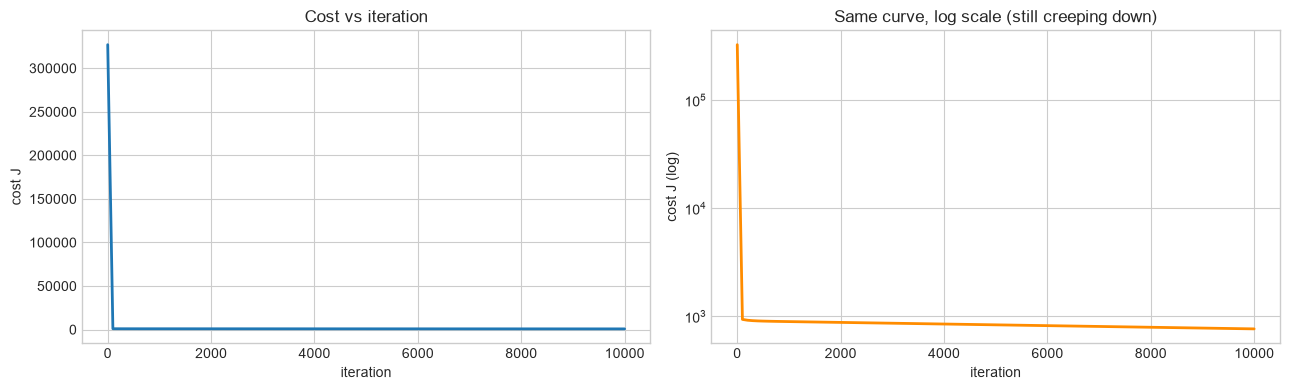

cost at iter 0      : 327,036.84
cost at the end     : 766.99
Monotonically decreasing and flattening -- gradient descent is working.


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
iters = [h[0] for h in J_history]
costs = [h[1] for h in J_history]

ax[0].plot(iters, costs, lw=2)
ax[0].set_title('Cost vs iteration')
ax[0].set_xlabel('iteration'); ax[0].set_ylabel('cost J')

ax[1].plot(iters, costs, lw=2, color='darkorange')
ax[1].set_yscale('log')
ax[1].set_title('Same curve, log scale (still creeping down)')
ax[1].set_xlabel('iteration'); ax[1].set_ylabel('cost J (log)')

plt.tight_layout(); plt.show()

print(f"cost at iter 0      : {costs[0]:,.2f}")
print(f"cost at the end     : {costs[-1]:,.2f}")
print("Monotonically decreasing and flattening -- gradient descent is working.")

## 6. Converting the weights back to real-world units

We trained on normalized features, so `w_norm` is in "dollars per standard deviation".
To get a model that eats **raw** specs, undo the scaling algebraically:

$$f = \sum_j w_{j,\text{norm}}\frac{x_j - \mu_j}{\sigma_j} + b_{\text{norm}}
    = \sum_j \underbrace{\frac{w_{j,\text{norm}}}{\sigma_j}}_{w_j}x_j
    + \underbrace{b_{\text{norm}} - \sum_j \frac{w_{j,\text{norm}}\mu_j}{\sigma_j}}_{b}$$

In [10]:
w_final = w_norm / sigma                       # (n,) dollars per raw unit
b_final = b_norm - np.sum(w_norm * mu / sigma) # scalar

print("=" * 68)
print("FINAL MODEL PARAMETERS  (raw, un-normalized units)")
print("=" * 68)
units = ['per inch', 'per GB', 'per GB', 'per kg', 'per GHz', 'per hour', 'if present']
for j, name in enumerate(feature_names):
    print(f"  w[{j}]  {name:>14s} = {w_final[j]:>12.2f}  $ {units[j]}")
print(f"\n  b     {'intercept':>14s} = {b_final:>12.2f}  $")
print("=" * 68)

print("\nprice ~= ")
print(f"    {b_final:,.2f}")
for j, name in enumerate(feature_names):
    print(f"  {'+' if w_final[j] >= 0 else '-'} {abs(w_final[j]):>10,.2f} * {name}")

# The two forms must agree -- same model, different coordinates.
assert np.allclose(X_train @ w_final + b_final, X_norm @ w_norm + b_norm)
print("\nCheck passed: raw-unit model and normalized model give identical predictions.")

FINAL MODEL PARAMETERS  (raw, un-normalized units)
  w[0]     screen_size =       227.02  $ per inch
  w[1]          ram_gb =        32.76  $ per GB
  w[2]      storage_gb =         1.15  $ per GB
  w[3]       weight_kg =     -1012.88  $ per kg
  w[4]       cpu_speed =       -92.85  $ per GHz
  w[5]    battery_life =       -23.33  $ per hour
  w[6]  is_touchscreen =       -14.07  $ if present

  b          intercept =     -1146.29  $

price ~= 
    -1,146.29
  +     227.02 * screen_size
  +      32.76 * ram_gb
  +       1.15 * storage_gb
  -   1,012.88 * weight_kg
  -      92.85 * cpu_speed
  -      23.33 * battery_life
  -      14.07 * is_touchscreen

Check passed: raw-unit model and normalized model give identical predictions.


## 7. How well does it fit?

In [11]:
def predict(X, w, b):
    """Predict prices for raw (un-normalized) feature rows."""
    return X @ w + b


y_pred = predict(X_train, w_final, b_final)
residuals = y_train - y_pred

print("  ID |   actual |  predicted |     error |  % error")
print("-" * 52)
for i in range(m):
    pct = 100 * residuals[i] / y_train[i]
    print(f"  {i+1:>2d} | ${y_train[i]:>7,.0f} | ${y_pred[i]:>9,.2f} | "
          f"{residuals[i]:>+9.2f} | {pct:>+7.2f}%")

mae  = np.mean(np.abs(residuals))
rmse = np.sqrt(np.mean(residuals ** 2))
ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((y_train - y_train.mean()) ** 2)
r2 = 1 - ss_res / ss_tot

print("-" * 52)
print(f"  MAE  (mean absolute error) : ${mae:,.2f}")
print(f"  RMSE (root mean sq. error) : ${rmse:,.2f}")
print(f"  R^2  (variance explained)  : {r2:.4f}")

  ID |   actual |  predicted |     error |  % error
----------------------------------------------------
   1 | $    750 | $   756.99 |     -6.99 |   -0.93%
   2 | $  1,200 | $ 1,185.24 |    +14.76 |   +1.23%
   3 | $    890 | $   923.00 |    -33.00 |   -3.71%
   4 | $  1,950 | $ 1,964.80 |    -14.80 |   -0.76%
   5 | $  1,100 | $ 1,041.28 |    +58.72 |   +5.34%
   6 | $  1,450 | $ 1,404.03 |    +45.97 |   +3.17%
   7 | $    420 | $   413.31 |     +6.69 |   +1.59%
   8 | $  1,050 | $ 1,121.35 |    -71.35 |   -6.80%
----------------------------------------------------
  MAE  (mean absolute error) : $31.54
  RMSE (root mean sq. error) : $39.17
  R^2  (variance explained)  : 0.9917


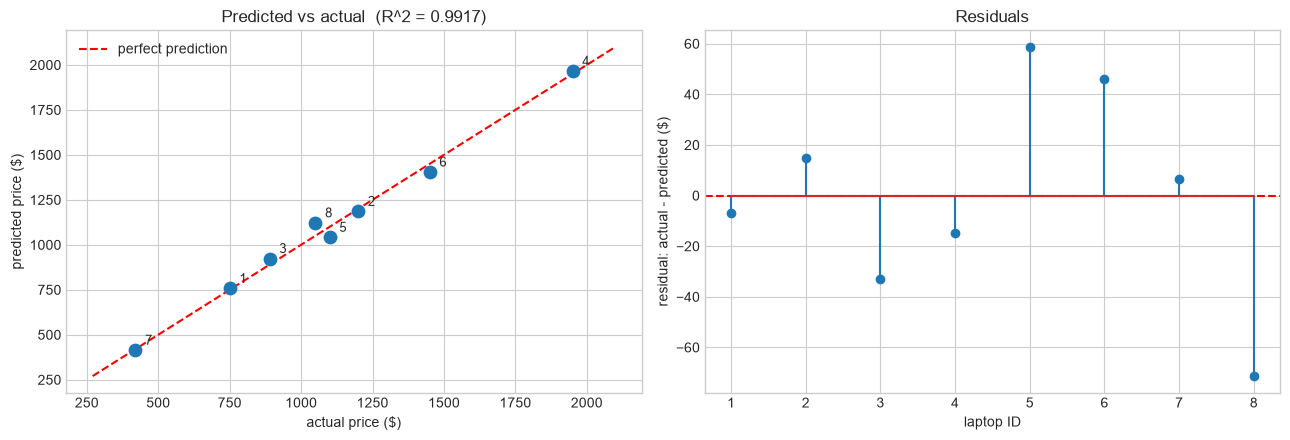

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

lo, hi = y_train.min() - 150, y_train.max() + 150
ax[0].scatter(y_train, y_pred, s=80, zorder=3)
ax[0].plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='perfect prediction')
for i in range(m):
    ax[0].annotate(f'{i+1}', (y_train[i], y_pred[i]),
                   textcoords='offset points', xytext=(7, 4), fontsize=9)
ax[0].set_xlabel('actual price ($)'); ax[0].set_ylabel('predicted price ($)')
ax[0].set_title(f'Predicted vs actual  (R^2 = {r2:.4f})')
ax[0].legend()

ax[1].axhline(0, color='r', ls='--', lw=1.5)
ax[1].stem(np.arange(1, m + 1), residuals)
ax[1].set_xlabel('laptop ID'); ax[1].set_ylabel('residual: actual - predicted ($)')
ax[1].set_title('Residuals')

plt.tight_layout(); plt.show()

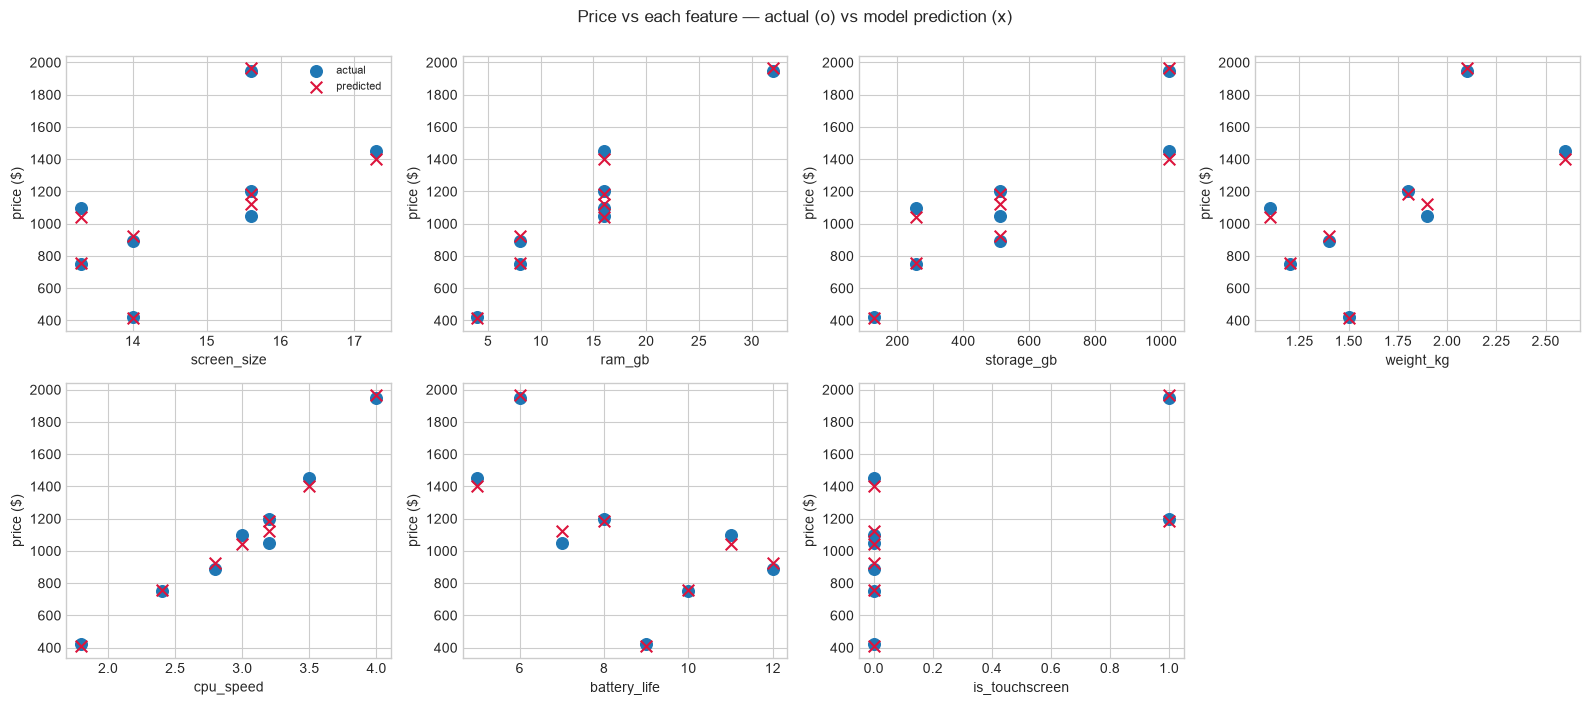

In [13]:
# Per-feature view: how each spec relates to price, with the fitted model's predictions on top.
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for j, axis in enumerate(axes.flat):
    if j >= n:
        axis.axis('off')
        continue
    axis.scatter(X_train[:, j], y_train, s=70, label='actual', zorder=3)
    axis.scatter(X_train[:, j], y_pred,  s=70, marker='x', color='crimson',
                 label='predicted', zorder=4)
    axis.set_xlabel(feature_names[j])
    axis.set_ylabel('price ($)')
    if j == 0:
        axis.legend(fontsize=8)
fig.suptitle('Price vs each feature — actual (o) vs model prediction (x)', y=1.0)
plt.tight_layout(); plt.show()

## 8. Reading the weights honestly

Two things about this dataset are worth being blunt about, because they change how much you
should trust the individual coefficients.

**a) We have 8 examples and 8 parameters (7 weights + 1 bias).** That is exactly enough to
memorize the data. A model with as many knobs as data points has no room left to be
"wrong", so the training-set $R^2$ is not evidence that the model generalizes — there's
no held-out data here at all.

**b) `screen_size` and `weight_kg` are almost perfectly correlated.** Bigger laptops are
heavier — obviously. When two features move together, the fit can trade one against the
other freely, and their individual coefficients become large, unstable, and sign-flipped
relative to intuition. That's why `weight_kg` comes out strongly *negative* below: it is
not "heavier laptops are cheaper", it's the counterweight to a large positive
`screen_size` coefficient.

Let's look at the correlations directly.

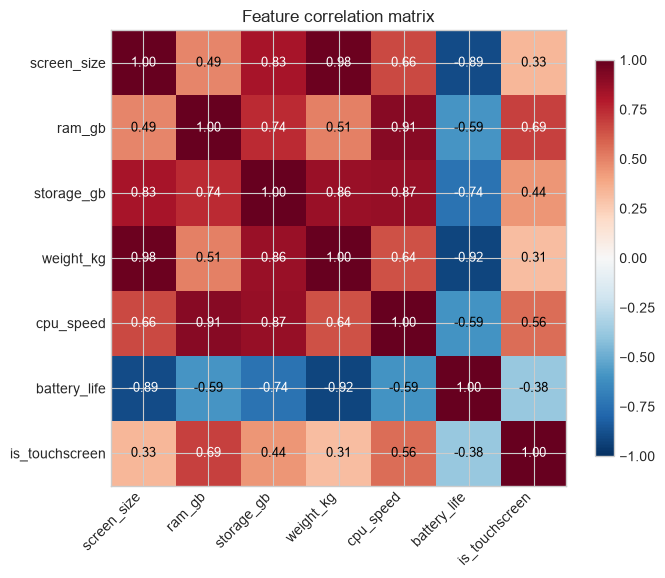

Strongly correlated feature pairs (|r| > 0.7):
     screen_size  <->  storage_gb      r = +0.826
     screen_size  <->  weight_kg       r = +0.981
     screen_size  <->  battery_life    r = -0.891
          ram_gb  <->  storage_gb      r = +0.744
          ram_gb  <->  cpu_speed       r = +0.912
      storage_gb  <->  weight_kg       r = +0.863
      storage_gb  <->  cpu_speed       r = +0.869
      storage_gb  <->  battery_life    r = -0.739
       weight_kg  <->  battery_life    r = -0.919

Condition number of the design matrix: 419.1
(A large value means the least-squares problem is ill-conditioned.)


In [14]:
corr = np.corrcoef(X_train, rowvar=False)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(feature_names, rotation=45, ha='right')
ax.set_yticks(range(n)); ax.set_yticklabels(feature_names)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center',
                fontsize=9, color='white' if abs(corr[i, j]) > 0.6 else 'black')
ax.set_title('Feature correlation matrix')
fig.colorbar(im, shrink=0.8)
plt.tight_layout(); plt.show()

print("Strongly correlated feature pairs (|r| > 0.7):")
for i in range(n):
    for j in range(i + 1, n):
        if abs(corr[i, j]) > 0.7:
            print(f"  {feature_names[i]:>14s}  <->  {feature_names[j]:<14s}  r = {corr[i, j]:+.3f}")

print(f"\nCondition number of the design matrix: {np.linalg.cond(np.c_[np.ones(m), X_norm]):,.1f}")
print("(A large value means the least-squares problem is ill-conditioned.)")

### What the model is confident about

Correlated pairs make *individual* weights unreliable, but the model as a whole is still
sensible. The way to see this is to compare each feature's contribution in **normalized**
units — dollars per standard deviation — which puts every feature on the same footing.

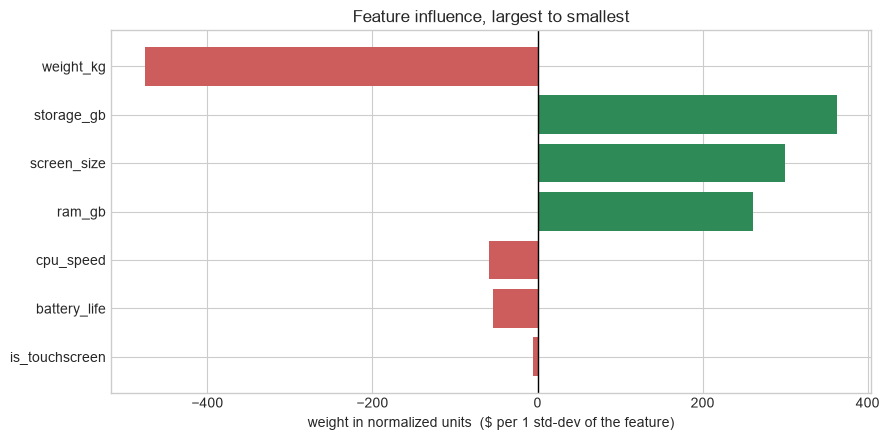

Ranked influence on price:
  1.      weight_kg  lowers price by ~$ 475.08 per std-dev
  2.     storage_gb  raises price by ~$ 362.70 per std-dev
  3.    screen_size  raises price by ~$ 299.66 per std-dev
  4.         ram_gb  raises price by ~$ 261.53 per std-dev
  5.      cpu_speed  lowers price by ~$  58.43 per std-dev
  6.   battery_life  lowers price by ~$  53.46 per std-dev
  7. is_touchscreen  lowers price by ~$   6.09 per std-dev

Storage, RAM and screen size dominate -- which matches how laptops are actually priced.
The weight_kg coefficient is an artifact of its 0.98 correlation with screen_size;
don't read it as 'heavy laptops are cheaper'.


In [15]:
order = np.argsort(np.abs(w_norm))[::-1]

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['seagreen' if w_norm[j] >= 0 else 'indianred' for j in order]
ax.barh([feature_names[j] for j in order], [w_norm[j] for j in order], color=colors)
ax.axvline(0, color='black', lw=1)
ax.invert_yaxis()
ax.set_xlabel('weight in normalized units  ($ per 1 std-dev of the feature)')
ax.set_title('Feature influence, largest to smallest')
plt.tight_layout(); plt.show()

print("Ranked influence on price:")
for rank, j in enumerate(order, 1):
    direction = 'raises' if w_norm[j] >= 0 else 'lowers'
    print(f"  {rank}. {feature_names[j]:>14s}  {direction} price by ~${abs(w_norm[j]):>7.2f} per std-dev")

print("\nStorage, RAM and screen size dominate -- which matches how laptops are actually priced.")
print("The weight_kg coefficient is an artifact of its 0.98 correlation with screen_size;")
print("don't read it as 'heavy laptops are cheaper'.")

## 9. Sanity check: compare against the closed-form solution

Linear regression has an exact solution — the **normal equation** — so we can check
gradient descent against it without any library beyond NumPy's least-squares solver:

$$\boldsymbol{\theta} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$$

In [16]:
A = np.c_[np.ones(m), X_norm]                      # prepend a column of 1s for the bias
theta, *_ = np.linalg.lstsq(A, y_train, rcond=None)
b_exact, w_exact = theta[0], theta[1:]

J_gd    = compute_cost(X_norm, y_train, w_norm,  b_norm)
J_exact = compute_cost(X_norm, y_train, w_exact, b_exact)

print(f"cost, gradient descent : {J_gd:>12,.4f}")
print(f"cost, normal equation  : {J_exact:>12,.6f}   <- essentially zero\n")

print(f"{'feature':>14s} | {'grad descent':>13s} | {'normal eqn':>13s}")
print("-" * 48)
for j, name in enumerate(feature_names):
    print(f"{name:>14s} | {w_norm[j]:>13.2f} | {w_exact[j]:>13.2f}")
print(f"{'bias':>14s} | {b_norm:>13.2f} | {b_exact:>13.2f}")

print(f"\n|w| gradient descent : {np.linalg.norm(w_norm):>10,.1f}")
print(f"|w| normal equation  : {np.linalg.norm(w_exact):>10,.1f}")

cost, gradient descent :     766.9908
cost, normal equation  :     0.000000   <- essentially zero

       feature |  grad descent |    normal eqn
------------------------------------------------
   screen_size |        299.66 |       4412.62
        ram_gb |        261.53 |       1782.68
    storage_gb |        362.70 |       2328.24
     weight_kg |       -475.08 |      -5326.43
     cpu_speed |        -58.43 |      -2620.32
  battery_life |        -53.46 |       -168.86
is_touchscreen |         -6.09 |       -394.87
          bias |       1101.25 |       1101.25

|w| gradient descent :      722.3
|w| normal equation  :    7,968.1


**This disagreement is the most interesting result in the notebook.**

The normal equation drives the cost to ~0 — it fits all 8 points perfectly, because it can.
It pays for that with enormous coefficients (thousands of dollars per standard deviation,
in both directions) that cancel each other out. That is textbook overfitting on a
collinear, parameter-saturated problem.

Gradient descent started at $\mathbf{w} = 0$ and hasn't gotten there yet, and its
weights stay small and interpretable. Stopping before convergence is acting as
**implicit regularization** — the same effect ridge regression gets explicitly.

Here, gradient descent's "worse" answer is the more useful model. On a real dataset with
hundreds of laptops the two would agree closely; they diverge here precisely because the
dataset is tiny.

## 10. Using the model on a new laptop

In [17]:
def predict_laptop(specs, w=w_final, b=b_final):
    """specs: dict keyed by feature name. Returns predicted price in USD."""
    x = np.array([specs[name] for name in feature_names], dtype=float)
    return float(x @ w + b)


new_laptops = [
    ("Budget ultrabook",  dict(screen_size=13.3, ram_gb=8,  storage_gb=256,  weight_kg=1.3,
                               cpu_speed=2.6, battery_life=11, is_touchscreen=0)),
    ("Mid-range 15\"",    dict(screen_size=15.6, ram_gb=16, storage_gb=512,  weight_kg=1.9,
                               cpu_speed=3.1, battery_life=8,  is_touchscreen=0)),
    ("Loaded workstation",dict(screen_size=17.3, ram_gb=32, storage_gb=1024, weight_kg=2.5,
                               cpu_speed=4.2, battery_life=5,  is_touchscreen=1)),
]

print(f"{'configuration':>20s} | {'predicted price':>16s}")
print("-" * 40)
for label, specs in new_laptops:
    print(f"{label:>20s} | ${predict_laptop(specs):>15,.2f}")

       configuration |  predicted price
----------------------------------------
    Budget ultrabook | $         613.80
       Mid-range 15" | $       1,107.30
  Loaded workstation | $       1,950.34


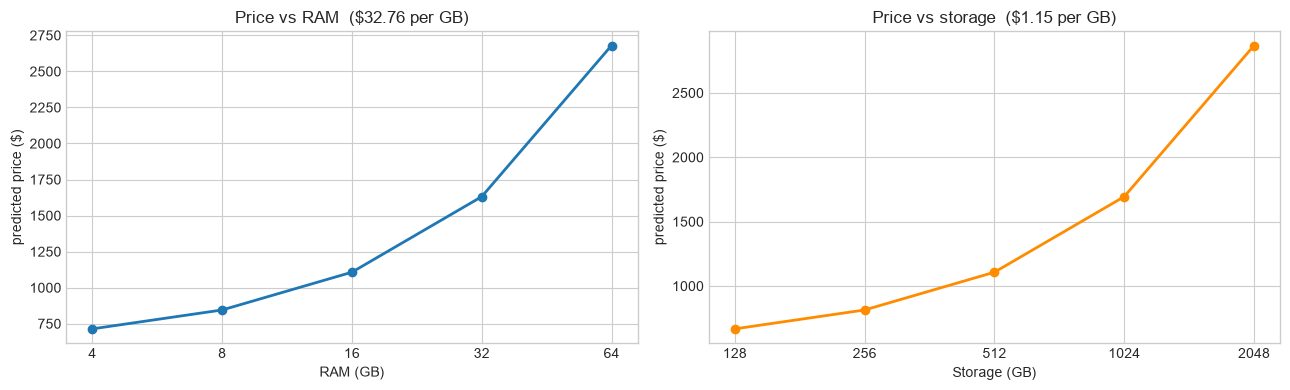

The model is linear, so these are straight lines -- doubling RAM from 32 to 64 GB
adds exactly as many dollars as going from 4 to 36 GB. Real pricing isn't linear,
which is a limit of the model, not a bug in the fit.


In [18]:
# Marginal effect: hold everything else fixed and sweep one feature.
base = dict(screen_size=15.6, ram_gb=16, storage_gb=512, weight_kg=1.9,
            cpu_speed=3.1, battery_life=8, is_touchscreen=0)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ram_values = np.array([4, 8, 16, 32, 64])
ram_prices = [predict_laptop({**base, 'ram_gb': r}) for r in ram_values]
ax[0].plot(ram_values, ram_prices, 'o-', lw=2)
ax[0].set_xscale('log', base=2)
ax[0].set_xticks(ram_values); ax[0].set_xticklabels(ram_values)
ax[0].set_xlabel('RAM (GB)'); ax[0].set_ylabel('predicted price ($)')
ax[0].set_title(f'Price vs RAM  (${w_final[1]:,.2f} per GB)')

sto_values = np.array([128, 256, 512, 1024, 2048])
sto_prices = [predict_laptop({**base, 'storage_gb': s}) for s in sto_values]
ax[1].plot(sto_values, sto_prices, 'o-', lw=2, color='darkorange')
ax[1].set_xscale('log', base=2)
ax[1].set_xticks(sto_values); ax[1].set_xticklabels(sto_values)
ax[1].set_xlabel('Storage (GB)'); ax[1].set_ylabel('predicted price ($)')
ax[1].set_title(f'Price vs storage  (${w_final[2]:,.2f} per GB)')

plt.tight_layout(); plt.show()

print("The model is linear, so these are straight lines -- doubling RAM from 32 to 64 GB")
print("adds exactly as many dollars as going from 4 to 36 GB. Real pricing isn't linear,")
print("which is a limit of the model, not a bug in the fit.")

## Summary

**What we did.** Fit a 7-feature multiple linear regression by hand: z-score normalization,
vectorized cost, vectorized gradient (checked against finite differences), batch gradient
descent, then converted the weights back to raw units.

**The answer.** With $\alpha = 0.3$ and 10,000 iterations, the fitted model is

$$\hat{y} = b + \sum_{j} w_j x_j$$

with the $w$ and $b$ printed in section 6, giving RMSE ≈ \$39 and $R^2 \approx 0.99$ on the
training data. Storage, RAM and screen size carry most of the signal.

**What to be careful about.**

- 8 examples, 8 parameters, no test set. The $R^2$ measures memorization, not generalization.
- `screen_size` ↔ `weight_kg` correlate at 0.98, so those two individual coefficients are not
  separately meaningful — only their combined effect is.
- The exact closed-form solution fits perfectly but with wild coefficients. Gradient descent's
  early stopping is the only thing keeping the weights sane.

**Natural next steps.** Add more rows; hold out a test set; add ridge (L2) regularization to
handle the collinearity explicitly; try polynomial or interaction features (RAM × CPU speed)
to capture the nonlinearity in real laptop pricing.